In [3]:
# import os
# import sys
# import math
# import logging
# from pathlib import Path
import psignifit as pf
import psignifit.priors as priors

import plotly
import plotly.express as px
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# from tqdm import tqdm

import numpy as np
import scipy as sp
from scipy.stats import gamma, lognorm, norm

import sklearn
from sklearn.linear_model import LinearRegression as LinReg
# import statsmodels.api as sm
# from statsmodels.formula.api import ols

%load_ext autoreload
%autoreload 2

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'


import pandas as pd
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
import json
import pandas as pd
import plotly.express as px
from psychoanalyze import data, plot
from datetime import datetime
from psychoanalyze.plot import template

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
curves = pd.read_csv('../data/2-calculated/curves2.csv', parse_dates=['Date'])
sessions = pd.read_csv('../data/2-calculated/sessions.csv', parse_dates=['Date','Days'])
impedances = pd.read_csv('../data/2-calculated/impedances.csv', parse_dates=['Date']).sort_values('Days')

curves = sessions.merge(curves)

## Figure 1 - Impedances

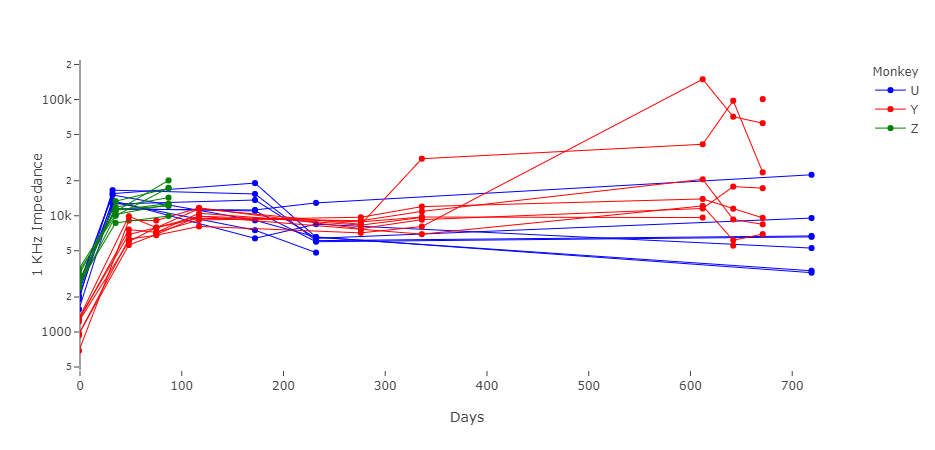

In [88]:
fig = px.line(impedances, color='Monkey',x='Days',y='1 KHz Impedance', line_group='Channel',
             category_orders={'Monkey':['U','Y','Z']}, template=template)
fig.update_traces(line_width=1, mode='lines+markers')
fig.update_yaxes(type='log')

### Figure 4a - All Monkeys, Single Channel

In [95]:
filters = {
    'experiment_type': 'detection', 
    'values':{
        'X dimension': 'Amp', 
        'Channel(s)':'1',
        'base':200,
    }
}
df_4a = data.filter(curves, **filters)
df_4a.to_csv('../data/4-external/fig4a.csv', index=False)

### Figure 4b - Monkey U, All Channels

In [9]:
filters = {
    'experiment_type': 'detection',
    'values':{
        'X dimension': 'Amp',
        'base':200, 
        'Monkey':'U',
        'Electrode Config': 'Monopolar'
    }
}
df4b = data.filter(curves, **filters)
df4b.to_csv('../data/4-external/fig4b.csv', index=False)

### Figure 4c - Monkey Y, All Channels

In [12]:
filters = {
    'experiment_type': 'detection',
    'values':{
        'X dimension': 'Amp',
        'base':200, 
        'Monkey':'Y', 
        'Electrode Config': 'Monopolar' }
}
df_4c = data.filter(curves, **filters)
df_4c.to_csv('../data/4-external/fig4c.csv')

## Figure 5 - Difference Thresholds

### Figure 5a - All Monkeys, Channels for Amplitude Dimension

In [25]:
filters = {
    'experiment_type': 'discrimination',
    'values': {
        'X dimension': 'Amp',
        'Electrode Config': 'Monopolar', 
        'base':200,
    },
#     'ranges': {
#         'Days':[100,1000],
#         'Ref Amp':[0,1200],
#     }
}
df_5a = data.filter(curves, **filters)
df_5a.to_csv('../data/4-external/5a.csv', index=False)

### Figure 5b - Monkey Y by channel

In [20]:
plot.figure('')

NameError: name 'figure_w_regression' is not defined

In [9]:
filters = {
    'experiment_type': 'discrimination', 
    'values': {
        'Monkey': 'Y', 
        'varparam': 'Amp',
        'Act Chan Mask':'00001111',
        'Ret Chan Mask':['00010000','10000000','00100000','0100000'], 
        'base':200
    }
}
df5b = data.filter(df, **filters)
groups = ['Monkey','Ref Amp','Channel(s)']
summary = df5b.groupby(groups)['location'].describe()
summary.head()
summary.to_csv('../data/4-external/fig5b.csv')
regressions = data.regress_groups(df5b,groups)
reg_data = json.dumps(regressions)
f = open("../data/4-external/fig5b_regressions.json","w")
f.write(reg_data)
f.close()

KeyError: 'varparam'

In [ ]:
### Figure 5c - Monkey  by channel